In [1]:
from diffusers import DiffusionPipeline  # noqa: E402
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import gc
from torchvision import transforms

tmpdir = '/home/qzhao9/code/sd_ft_lora/diffuusers/diffusers/examples/text_to_image/sd-kvasir-model-lora/checkpoint-2500'

pipe = DiffusionPipeline.from_pretrained(
"CompVis/stable-diffusion-v1-4", safety_checker=None
)
pipe.load_lora_weights(tmpdir)


/home/qzhao9/miniconda3/envs/sd_ft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 41.49it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
N

In [2]:
import numpy as np

eval_cfg = {
    'num_inference_steps': 20,
    'guidance_scale': 8.5,
    'height': 512,
    'width': 512,
    'generator': torch.Generator(device='cuda').manual_seed(27),
    'negative_prompt':'Do NOT generate text, timestamp,or box at any corner of the image.'
    }

eval_prompts = [
    "A detailed endoscopic image showing inflamed mucosa with ulcerations and erythema, indicative of active ulcerative colitis.",
    "An endoscopic view of the colon revealing multiple polyps of varying sizes, some with a sessile appearance, requiring biopsy for histopathological evaluation.",
    "A high-resolution endoscopic image capturing a bleeding gastric ulcer with visible vessel, surrounded by edematous and erythematous tissue." 
    "endoscopic image of the colon with realistic mucosal texture and lighting",
    "endoscopic view of the colonic lumen with natural illumination and shadows",
    "wide-angle endoscopic view of colon interior"  
]

def evaluate_model(pipe, prompts, eval_cfg, global_step, save_path=None):
    # pipe.unet.eval()
    images = []
    for i, prompt in enumerate(prompts):
        image = pipe(prompt, **eval_cfg ).images[0]
        images.append(image)
    grid = vutils.make_grid([transforms.ToTensor()(img) for img in images], nrow=len(prompts))
    plt.figure(figsize=(5*len(prompts),5))
    plt.axis('off')
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    if save_path:
        plt.savefig(save_path, dpi=600)
    plt.show()

In [3]:
pipe.device.type == 'cpu' and torch.cuda.is_available()

True

100%|██████████| 20/20 [00:05<00:00,  3.49it/s]


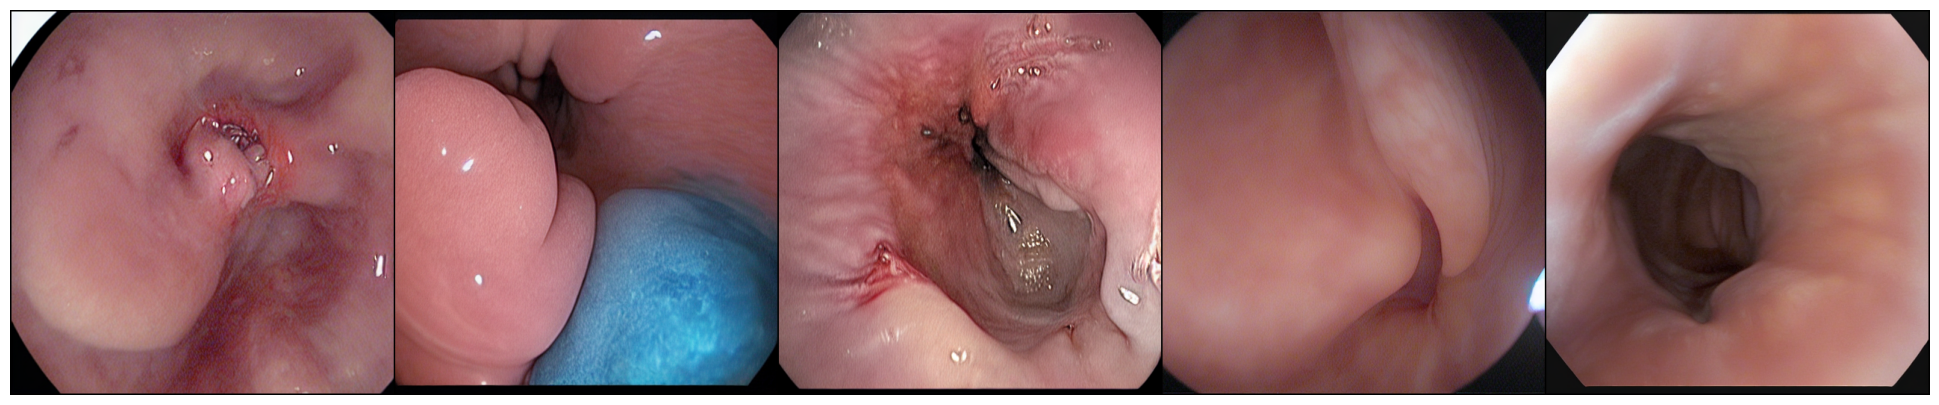

In [4]:
if pipe.device.type == 'cpu' and torch.cuda.is_available():
    pipe.to('cuda')
evaluate_model(pipe, eval_prompts, eval_cfg,0)